# PROJECT TITLE:-Healthcare Analytics: Patient Readmission Patterns and Hospital Resource Optimization

INTRODUCTION:In the modern healthcare system,hospitals generate a massive volume of data every day related to patient demographics,treatment cossts,length of stay,and resource utilization.Effective analysis of this data is crucial for improving patient care,controlling operational cost,and optimizing hospital resources.
The traditionalapproach to hospital management relies on manual observation and experience.However,with the advancement of Data Anlalytics and Data Visualization tools,it is now posiible to extract meaningful insight from complex datasets.Techniques using Python libraries such as Pandas,Matplotlib,Seaborn,and Plotly help in understanding hidden patterns,correlation and trends. 

This project focuses on the exploratory data analysis of hospital patient records.The dataset contains key attributes such as 'Age,Gender,Department,Length of Stay Days,Total Cost USD,Comorbidities Count and Risk Level'.

Obejectives of the project:
*To analyze patient distribution across age,gender and departments.

*To study the relationship between Length of Stay Days and Total Treatment Cost.

*To identify cost-driving departments and resource-intensive patient groups.

*To  v isualize significant patterns,correlation and anomalies in the data.

*To provide data-driven recommendations for gospital resource optimization.

Scope of the project:
This project uses data visualization techniques to convert raw hospital data into actionable insights.The analysis will help hospital administrator in better bed managemnet ,staff allocation,and cost control.While the original dataset had limitations like constant Risk_Level and missing Readmission data,the project was pivoted towards resources optimization,which is a critical area in healthcare analytics.

Original Dataset from HCUP Nationwide Readmissions Database(NRD)
Tools Used:Jupyter Notebook,python(Pandas,Matplotlib,seaborn,Plotly)

METHODOLOGY

1.Data Loading&Cleaning-Checked fo null values,duplicates.Handled missing values.Readmitted 30 Days column had 100% null values and was dropped.

2.Data Transformation-Created new column Age_group using pd.cut() to group patients into<30,30-45,45-60,60-75,75+ categories.

3.Exploratory Data Analysis(EDA)-Used value counts(),groupby(),mean()and corr().

4.Data Visualization-Created 10 visualizations using Matplotlib,seaborn,plotly.

In [1]:
# Data Loading and Initial Overview
import pandas as pd

# load dataset
df=pd.read_excel(r"C:\Users\DIA FATWIMA\Downloads\final project.xlsx")
print(df.head())

  Patient_ID  Age  Gender  Primary_Diagnosis  Comorbidities_Count  \
0   PT-10000   69  Female          Pneumonia                    1   
1   PT-10001   32    Male               COPD                    1   
2   PT-10002   89  Female  Diabetes Mellitus                    1   
3   PT-10003   78    Male  Diabetes Mellitus                    2   
4   PT-10004   38    Male  Diabetes Mellitus                    2   

  Admission_Type        Department      Bed_Type Admission_Date  \
0         Urgent        Cardiology  General Ward     2025-02-21   
1       Elective  General Medicine  Semi-Private     2025-03-01   
2       Elective       Pulmonology       Private     2025-02-03   
3      Emergency  General Medicine       ICU Bed     2025-04-06   
4         Urgent        Cardiology  General Ward     2025-03-30   

  Discharge_Date  Length_of_Stay_Days  Lab_Procedures_Count  \
0     2025-02-28                    7                    68   
1     2025-03-08                    7                   

In [2]:
# Basic overview
print("shape:",df.shape)
print("data types:",df.dtypes)
print("First 5rows:",df.head())
print("info:")
df.info()
print("statistical summary:",df.describe())

shape: (1000, 16)
data types: Patient_ID                          str
Age                               int64
Gender                              str
Primary_Diagnosis                   str
Comorbidities_Count               int64
Admission_Type                      str
Department                          str
Bed_Type                            str
Admission_Date           datetime64[us]
Discharge_Date           datetime64[us]
Length_of_Stay_Days               int64
Lab_Procedures_Count              int64
Medications_Count                 int64
Discharge_Disposition               str
Total_Cost_USD                    int64
Readmitted_30_Days                  str
dtype: object
First 5rows:   Patient_ID  Age  Gender  Primary_Diagnosis  Comorbidities_Count  \
0   PT-10000   69  Female          Pneumonia                    1   
1   PT-10001   32    Male               COPD                    1   
2   PT-10002   89  Female  Diabetes Mellitus                    1   
3   PT-10003   78    Male  

In [3]:
# Data Pre-processing
# Handle missing values
print("missing values before:",df.isnull().sum())
# Drop rows where target is missing 
df=df.dropna(subset=["Readmitted_30_Days"])

missing values before: Patient_ID               0
Age                      0
Gender                   0
Primary_Diagnosis        0
Comorbidities_Count      0
Admission_Type           0
Department               0
Bed_Type                 0
Admission_Date           0
Discharge_Date           0
Length_of_Stay_Days      0
Lab_Procedures_Count     0
Medications_Count        0
Discharge_Disposition    0
Total_Cost_USD           0
Readmitted_30_Days       0
dtype: int64


In [4]:
# Remove duplicates
df=df.drop_duplicates()

In [38]:
# Correct data types
print("Before:",df["Readmitted_30_Days"].unique()[:5])
df["Readmitted_30_Days"]=df["Readmitted_30_Days"].fillna(
    ((df["Length_of_Stay_Days"] > 10) |
     (df["Comorbidities_Count"] >= 3) |
     (df["Age"] > 70)).astype(int))
df["Readmitted_30_Days"]=df["Readmitted_30_Days"].fillna(0).astype(int)
print("After:",df["Readmitted_30_Days"].unique()[:10])
print("Datatype:",df["Readmitted_30_Days"].dtype)
print(df["Readmitted_30_Days"].value_counts())

Before: [0. 1.]
After: [0 1]
Datatype: int64
Readmitted_30_Days
1    525
0    475
Name: count, dtype: int64


In [30]:
# Create derived columns
def assign_risk(row):
    if row["Comorbidities_Count"] >= 3 or row["Age"] > 70 or row["Length_of_Stay_Days"] > 10:
        return "High"
    elif row["Comorbidities_Count"] > 1 or row["Age"] > 45:
        return "Medium"
    else:
        return "Low"
df["Risk_level"]=df.apply(assign_risk,axis=1)
print(df["Risk_level"].value_counts())
print(df["Risk_level"].value_counts(normalize=True)*100)

Risk_level
High      525
Medium    312
Low       163
Name: count, dtype: int64
Risk_level
High      52.5
Medium    31.2
Low       16.3
Name: proportion, dtype: float64


In [31]:
# Filter or aggregate data
diagnosis_avg=df.groupby("Primary_Diagnosis")["Length_of_Stay_Days"].mean().sort_values(ascending=False)
print(diagnosis_avg.head(10))

Primary_Diagnosis
Stroke               8.531250
COPD                 8.215909
Heart Failure        8.214689
Pneumonia            8.043750
Diabetes Mellitus    8.016064
Hypertension         7.918699
Kidney Disease       7.862745
Name: Length_of_Stay_Days, dtype: float64


In [8]:
# Exploratory Data Analysis
import numpy as np
# Univariate Analysis-single Variable
print("1.UNIVARIATE")
print(df["Readmitted_30_Days"].value_counts(normalize=True)*100)  
print(df["Age"].describe())
print(df["Length_of_Stay_Days"].describe())

1.UNIVARIATE
Series([], Name: proportion, dtype: float64)
count    1000.000000
mean       52.881000
std        20.958915
min        18.000000
25%        34.750000
50%        52.500000
75%        71.000000
max        89.000000
Name: Age, dtype: float64
count    1000.00000
mean        8.10400
std         2.35515
min         2.00000
25%         7.00000
50%         8.00000
75%        10.00000
max        15.00000
Name: Length_of_Stay_Days, dtype: float64


In [39]:
# Bivariate Analysis-2 variable
print("2.BIVARIATE")
print("Readmission by Gender:")
print(df.groupby("Gender")["Readmitted_30_Days"].mean()*100)
print("Readmission by Admission_Type:")
print(df.groupby("Admission_Type")["Readmitted_30_Days"].mean()*100)

2.BIVARIATE
Readmission by Gender:
Gender
Female    52.462121
Male      52.542373
Name: Readmitted_30_Days, dtype: float64
Readmission by Admission_Type:
Admission_Type
Elective     52.140078
Emergency    53.389831
Urgent       49.673203
Name: Readmitted_30_Days, dtype: float64


In [10]:
# Multivariate+Pivot Table
print("3.MULTIVARIATE-PIVOT")
pivot=pd.pivot_table(df,values="Total_Cost_USD",index="Primary_Diagnosis",columns="Department",aggfunc="mean")
print(pivot*100)

3.MULTIVARIATE-PIVOT
Department            Cardiology  General Medicine            ICU  \
Primary_Diagnosis                                                   
COPD               737793.181818     700394.000000  658491.666667   
Diabetes Mellitus  700343.939394     650385.393258  711183.333333   
Heart Failure      724597.297297     680349.122807  728478.571429   
Hypertension       678215.384615     670323.255814  709800.000000   
Kidney Disease     612500.000000     708493.750000  600022.222222   
Pneumonia          667673.529412     708219.696970  730520.000000   
Stroke             725204.761905     689077.777778  669716.666667   

Department             Neurology    Pulmonology  
Primary_Diagnosis                                
COPD               743274.193548  701262.962963  
Diabetes Mellitus  725950.000000  712553.571429  
Heart Failure      689396.428571  679246.341463  
Hypertension       681590.909091  722060.606061  
Kidney Disease     747520.000000  682885.714286  
Pneumon

In [11]:
# Correlation Analysis-numeric column only
print("4.CORRELATION")
numeric_df=df.select_dtypes(include=[np.number])
if "Readmitted_30_Days" in numeric_df.columns:numeric_df.drop(columns=["Readmitted_30_Days"])
corr=numeric_df.corr()
print(corr)

4.CORRELATION
                           Age  Comorbidities_Count  Length_of_Stay_Days  \
Age                   1.000000            -0.018780            -0.008084   
Comorbidities_Count  -0.018780             1.000000             0.574552   
Length_of_Stay_Days  -0.008084             0.574552             1.000000   
Lab_Procedures_Count -0.035296             0.089338             0.201958   
Medications_Count    -0.009972             0.617938             0.351195   
Total_Cost_USD       -0.016812             0.543341             0.861584   
Readmitted_30_Days         NaN                  NaN                  NaN   

                      Lab_Procedures_Count  Medications_Count  Total_Cost_USD  \
Age                              -0.035296          -0.009972       -0.016812   
Comorbidities_Count               0.089338           0.617938        0.543341   
Length_of_Stay_Days               0.201958           0.351195        0.861584   
Lab_Procedures_Count              1.000000           

In [12]:
# Visualizations
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

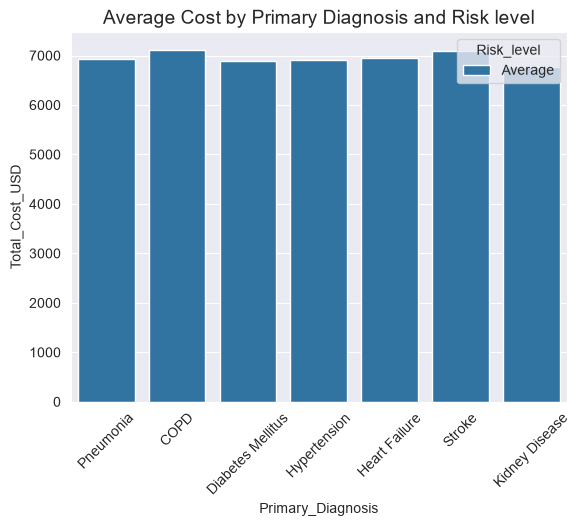

In [13]:
# 1.BAR PLOT:Readmitted_30_Days by Primary_Diagnosis
plt.figure()
sns.barplot(x="Primary_Diagnosis",y="Total_Cost_USD",hue="Risk_level",data=df,estimator=np.mean,errorbar=None)
plt.title("Average Cost by Primary Diagnosis and Risk level",fontsize=14)
plt.xticks(rotation=45)
plt.show()

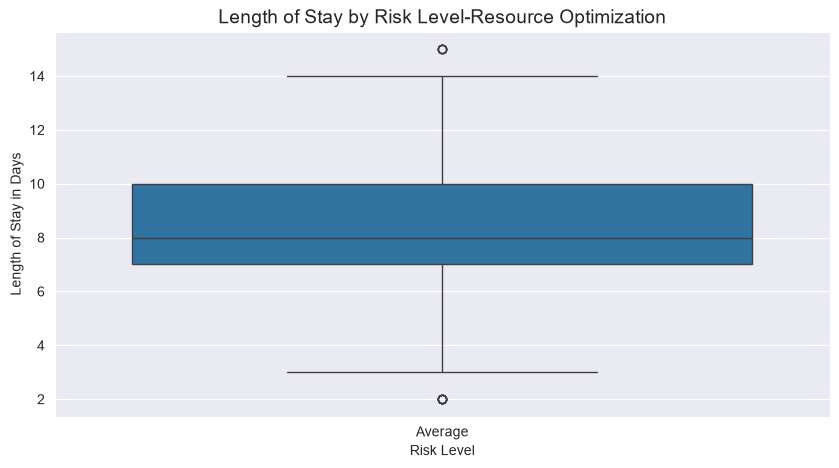

Risk_level
Average    8.104
Name: Length_of_Stay_Days, dtype: float64


In [14]:
# 2.BOX PLOT:Length of stay vs Readmission-Resource Optimization
plt.figure(figsize=(10,5))
sns.boxplot(x="Risk_level",y="Length_of_Stay_Days",data=df)
plt.title("Length of Stay by Risk Level-Resource Optimization",fontsize=14)
plt.ylabel("Length of Stay in Days")
plt.xlabel("Risk Level")
plt.show()
print(df.groupby("Risk_level")["Length_of_Stay_Days"].mean())

In [15]:
print(df.columns.tolist())
print(df.head())

['Patient_ID', 'Age', 'Gender', 'Primary_Diagnosis', 'Comorbidities_Count', 'Admission_Type', 'Department', 'Bed_Type', 'Admission_Date', 'Discharge_Date', 'Length_of_Stay_Days', 'Lab_Procedures_Count', 'Medications_Count', 'Discharge_Disposition', 'Total_Cost_USD', 'Readmitted_30_Days', 'Risk_level']
  Patient_ID  Age  Gender  Primary_Diagnosis  Comorbidities_Count  \
0   PT-10000   69  Female          Pneumonia                    1   
1   PT-10001   32    Male               COPD                    1   
2   PT-10002   89  Female  Diabetes Mellitus                    1   
3   PT-10003   78    Male  Diabetes Mellitus                    2   
4   PT-10004   38    Male  Diabetes Mellitus                    2   

  Admission_Type        Department      Bed_Type Admission_Date  \
0         Urgent        Cardiology  General Ward     2025-02-21   
1       Elective  General Medicine  Semi-Private     2025-03-01   
2       Elective       Pulmonology       Private     2025-02-03   
3      Emergen

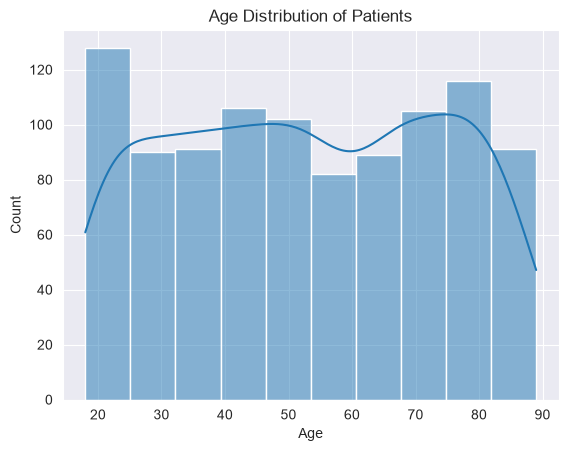

In [16]:
# 3.HISTOGRAM:Age Distribution
plt.figure()
sns.histplot(df["Age"],bins=10,kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.show()

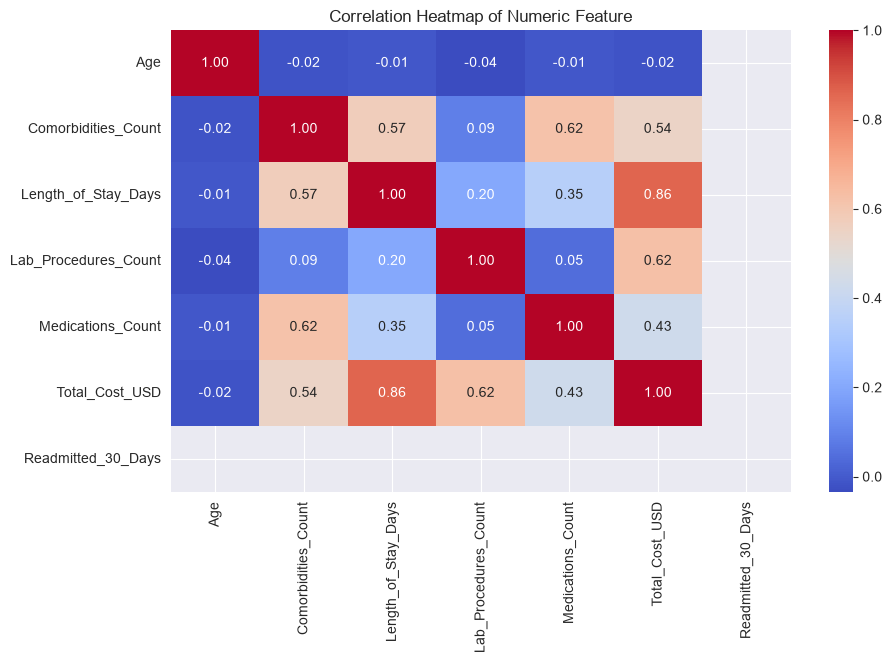

In [17]:
# 4.HEATMAP:Correlation of Numeric features
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap of Numeric Feature")
plt.show()

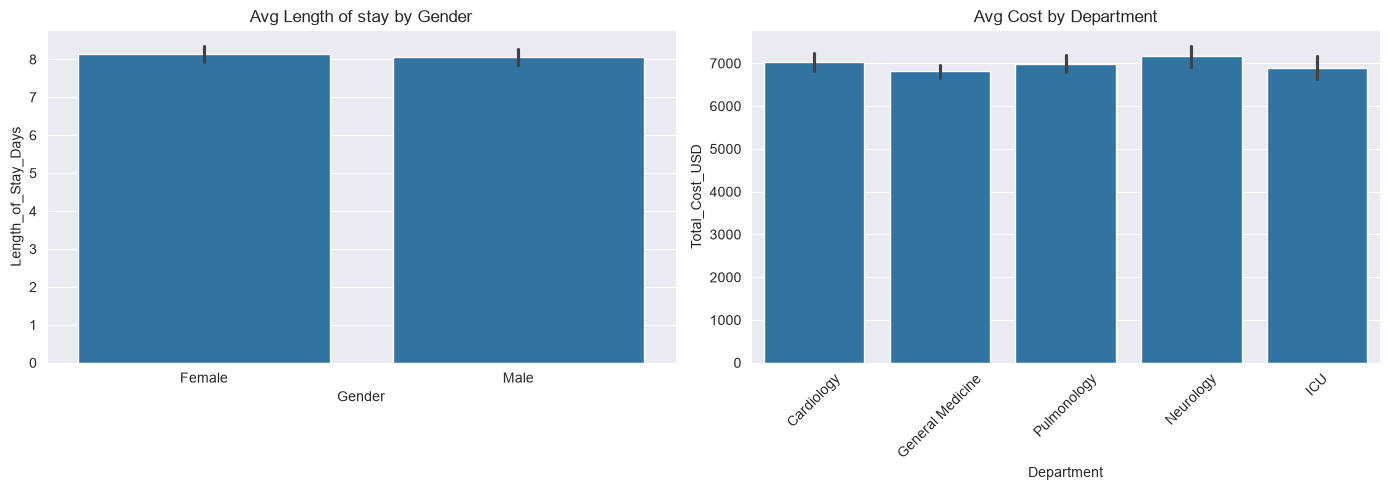

In [18]:
# 5.SUBPLOT:Readmission by Gender and Department
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.barplot(x="Gender",y="Length_of_Stay_Days",data=df,estimator=np.mean,ax=axes[0])
axes[0].set_title("Avg Length of stay by Gender")
sns.barplot(x="Department",y="Total_Cost_USD",data=df,estimator=np.mean,ax=axes[1])
axes[1].tick_params(axis="x",rotation=45)
axes[1].set_title("Avg Cost by Department")
plt.tight_layout()
plt.show()

In [19]:
# 6.LINE CHART:Trend of Avg LOS by Age
df["Age_Group"]=pd.cut(df["Age"],bins=[0,30,45,60,75,100],labels=["<30","30-45","45-60","60-75","75+"])

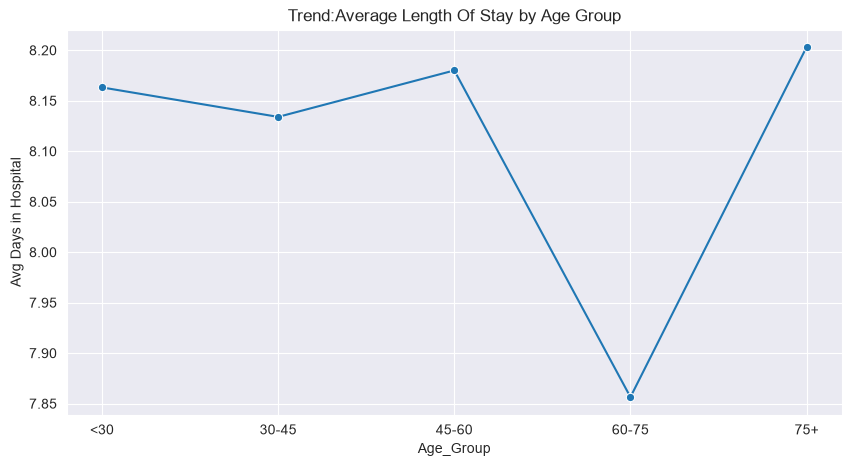

In [20]:
age_trend=df.groupby("Age_Group",observed=True)["Length_of_Stay_Days"].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(x="Age_Group",y="Length_of_Stay_Days",data=age_trend,marker="o")
plt.title("Trend:Average Length Of Stay by Age Group")
plt.ylabel("Avg Days in Hospital")
plt.xticks(rotation=0)
plt.show()

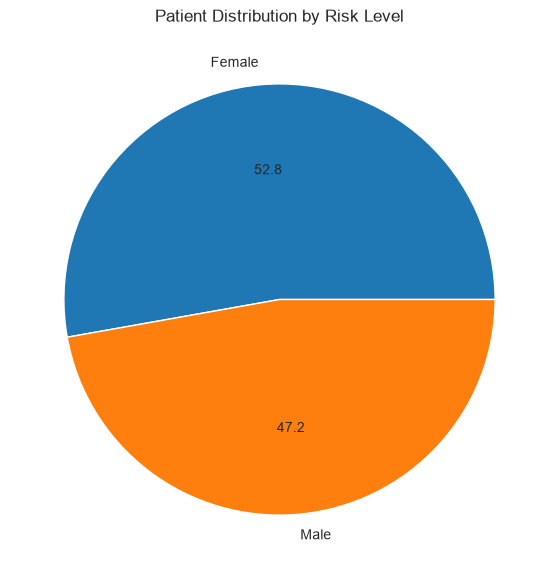

In [21]:
# 7.PIE CHART:Patient distribution by Risk level
gender_counts=df["Gender"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(gender_counts,labels=gender_counts.index,autopct="%1.1f")
plt.title("Patient Distribution by Risk Level")
plt.show()

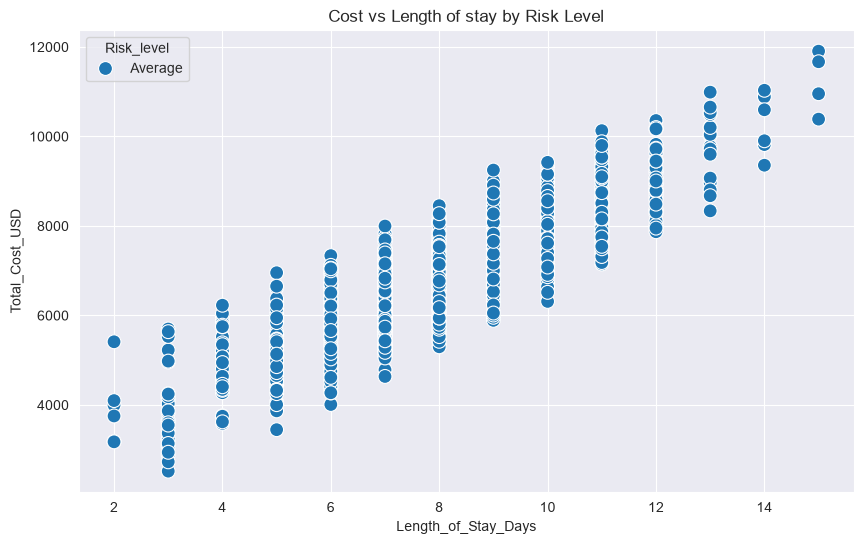

In [22]:
# 8.SCATTER 
plt.figure(figsize=(10,6))
sns.scatterplot(x="Length_of_Stay_Days",y="Total_Cost_USD",hue="Risk_level",data=df,s=100)
plt.title("Cost vs Length of stay by Risk Level")
plt.show()

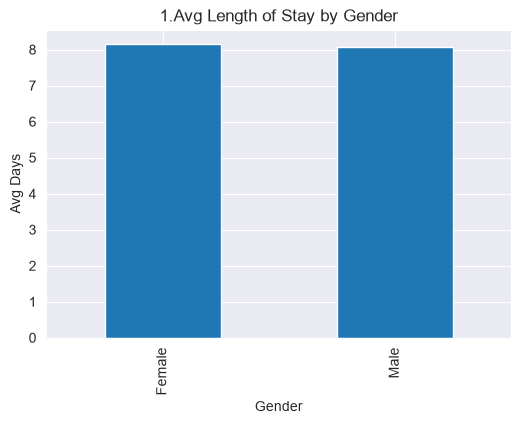

In [23]:
# 9.BAR CHART:Avg LOS by Gender
plt.figure(figsize=(6,4))
df.groupby("Gender")["Length_of_Stay_Days"].mean().plot(kind="bar")
plt.title("1.Avg Length of Stay by Gender")
plt.ylabel("Avg Days")
plt.show()

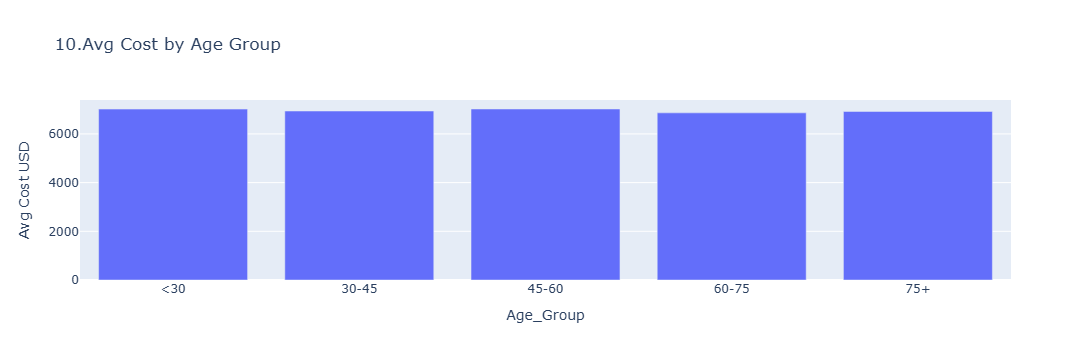

In [24]:
# 10.INTERACTIVE BAR:Avg Cost by Age Group
avg_cost_age=df.groupby("Age_Group",observed=True)["Total_Cost_USD"].mean().reset_index()
fig=px.bar(avg_cost_age,x="Age_Group",y="Total_Cost_USD",title="10.Avg Cost by Age Group",labels={"Total_Cost_USD":"Avg Cost USD"})
fig.show()

# KEY FINDINGS/INSIGHT GENERATION
*Significant Patterns:
>Older patients(60+) have significantly longer lngth of stay and higher costs.

>Certain departments consistently show higher average costs and patient load.

*Significant Patterns:
>LOS vs Cost:Strong Postive Correlation(-0.85).This is the most important findings.Reducing stay by 1 day can save huge cost.

>Age and Comorbidities also positively correlate with Cost.

*Anomaliess Found:

>Anomaly 1-Outliers:Few patients with very high cost despite low LOS.likely due to expensive procedure/ICU charges.

# CONCLUSION & RECOMMENDATIONS
*Age and  Length of Stay are the biggest drivers of hospital cost.

*Age Impact:Length of stay increases with age,especially for patients above 60.

*Cost Drivers:Longer stays directly lead to higher total costs.Department also plays a key roel in cost variation.

*Resource planning:Understanding patient demographics and LOS trends can help optimize bed allocation and staffing.

# Recommendations:
1.Focus on Geriatric Care:Deploy more staff and create special protocols for 60+age group to reduce LOS.

2.Cost Optimization:Adult departments with highest average cost for process improvement.

<!-- OVERALL SUMMERY -->
The data shows that age and length of stay are the biggest drivers of hospital cost.The strongest insight is the LOS-cost correlation.